# VIX Mean Reversion Strategy — Full Backtest

**Instrument:** SVXY (short volatility ETF)
**Signal:** Buy SVXY during VIX spikes, exit when volatility normalizes (Simple variant).
**Data:** VIX from WRDS, SVXY from Alpaca.

**Three scenarios tested:**
1. **Post-2018 only** — clean period, SVXY at -0.5x (what we validated)
2. **Full history (2011–2026), no stop loss** — includes Volmageddon, dynamic sizing
3. **Full history (2011–2026), -20% stop loss** — survivability test

Pre-2018 SVXY was -1x VIX futures, so allocation is halved (47.5%) to equalize
economic exposure across both periods.

Uses `shared/` for data, fees, metrics, significance, and results.

## 1. Setup

In [19]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.loaders_wrds import load_vix
from _shared.fees import calculate_fees
from _shared.metrics import evaluate_strategy, print_metrics, compare_strategies
from _shared.plotting import plot_equity_curve, plot_trade_returns, plot_yearly_returns
from _shared.significance import full_significance_report, print_significance_report
from _shared.results import save_trades

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Configuration

In [20]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOL     = "SVXY"
START_FULL = "2011-10-01"   # SVXY launched Oct 2011
START_POST = "2018-03-01"   # Post-Volmageddon
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000

# ── Leverage Transition ──
VOLMAGEDDON_DATE   = pd.Timestamp("2018-02-27")  # SVXY switched to -0.5x
ALLOC_PRE_2018     = 0.475   # Half allocation when SVXY was -1x
ALLOC_POST_2018    = 0.95    # Full allocation when SVXY is -0.5x

# ── Spike Detection ──
VIX_SPIKE_MIN      = 18
SMA_SPIKE          = 40
SPIKE_SMA_MULT     = 1.10

# ── Technical Indicators ──
EMA_SHORT          = 7
EMA_LONG           = 18
STOCH_K            = 7
STOCH_SMOOTH       = 3
STOCH_D            = 3

# ── Regime Thresholds ──
VIX_NORMAL_MAX     = 30
VIX_30_MAX         = 40
VIX_AUTOBUY_MIN    = 45

# ── Immunity ──
IMMUNITY_NORMAL    = 2
IMMUNITY_VIX30     = 5
IMMUNITY_VIX40     = 5

# ── Post-Exit Protection ──
COOLDOWN_DAYS      = 2
ENHANCED_DAYS      = 5

# ── Stop Loss ──
STOP_LOSS_PCT      = -0.20   # -20% stop loss

# ── Volmageddon Exclusion Dates ──
VOLMAGEDDON_EXCLUSIONS = pd.to_datetime([
    "2018-02-05", "2018-02-06", "2018-02-07", "2018-02-08", "2018-02-09",
])

INCLUDE_FEES = True

## 3. Data Fetching

In [21]:
# ── Fetch SVXY from Alpaca — full history ──
data_dict = fetch_historical_data(
    [SYMBOL], TimeFrame(1, TimeFrameUnit.Day), START_FULL, END_DATE)

svxy = data_dict[SYMBOL].copy()
if svxy.index.tz is None:
    svxy.index = svxy.index.tz_localize("UTC").tz_convert("US/Eastern")
else:
    svxy.index = svxy.index.tz_convert("US/Eastern")

svxy = svxy.reset_index()
svxy["date"] = svxy["timestamp"].dt.date
svxy = svxy.groupby("date").last().reset_index()
svxy["date"] = pd.to_datetime(svxy["date"])

print(f"SVXY bars: {len(svxy):,}")
print(f"Date range: {svxy['date'].iloc[0].date()} → {svxy['date'].iloc[-1].date()}")
print(f"Price range: ${svxy['close'].min():.2f} → ${svxy['close'].max():.2f}")

Fetching SVXY...
  2,575 bars
SVXY bars: 2,575
Date range: 2016-01-04 → 2026-03-31
Price range: $13.14 → $276.42


In [22]:
# ── Load VIX from WRDS ──
WRDS_DATA_DIR = "../wrds_data"
vix_raw = load_vix(start_date=START_FULL, end_date=END_DATE, data_dir=WRDS_DATA_DIR)
vix = vix_raw[["date", "vix", "vixo", "vixh", "vixl"]].copy()
vix = vix.dropna(subset=["vix"]).reset_index(drop=True)

# ── Merge ──
df = svxy.merge(vix, on="date", how="inner", suffixes=("", "_vix"))
df = df.sort_values("date").reset_index(drop=True)
print(f"Merged bars: {len(df):,}")
print(f"Date range: {df['date'].iloc[0].date()} → {df['date'].iloc[-1].date()}")

# Mark pre/post Volmageddon
df["is_pre_2018"] = df["date"] < VOLMAGEDDON_DATE
print(f"Pre-2018 days: {df['is_pre_2018'].sum()}")
print(f"Post-2018 days: {(~df['is_pre_2018']).sum()}")

Loaded 15_cboe_vix.parquet: 10,678 rows x 17 cols
Merged bars: 2,575
Date range: 2016-01-04 → 2026-03-31
Pre-2018 days: 541
Post-2018 days: 2034


## 4. Technical Indicators

In [23]:
# EMAs on VIX highs
df["vix_ema7"] = df["vixh"].ewm(span=EMA_SHORT, adjust=False).mean()
df["vix_ema18"] = df["vixh"].ewm(span=EMA_LONG, adjust=False).mean()

# SMA40
df["vix_sma40"] = df["vix"].rolling(window=SMA_SPIKE).mean()

# Stochastic
vix_low_min = df["vixl"].rolling(window=STOCH_K).min()
vix_high_max = df["vixh"].rolling(window=STOCH_K).max()
raw_k = 100 * (df["vix"] - vix_low_min) / (vix_high_max - vix_low_min)
df["stoch_k"] = raw_k.rolling(window=STOCH_SMOOTH).mean()
df["stoch_d"] = df["stoch_k"].rolling(window=STOCH_D).mean()

# Trends
df["ema7_declining"] = df["vix_ema7"] < df["vix_ema7"].shift(1)
df["ema18_declining"] = df["vix_ema18"] < df["vix_ema18"].shift(1)

# Spike detection
df["vix_spike"] = (df["vix"] >= VIX_SPIKE_MIN) & (df["vix"] > df["vix_sma40"] * SPIKE_SMA_MULT)

# Volmageddon exclusion
df["is_volmageddon"] = df["date"].isin(VOLMAGEDDON_EXCLUSIONS)

print(f"Spike days: {df['vix_spike'].sum()} / {len(df)} ({df['vix_spike'].mean()*100:.1f}%)")
print(f"VIX > 30: {(df['vix'] >= 30).sum()} days")
print(f"VIX > 45: {(df['vix'] >= 45).sum()} days")

Spike days: 427 / 2575 (16.8%)
VIX > 30: 154 days
VIX > 45: 26 days


## 5. Exploratory — Full History

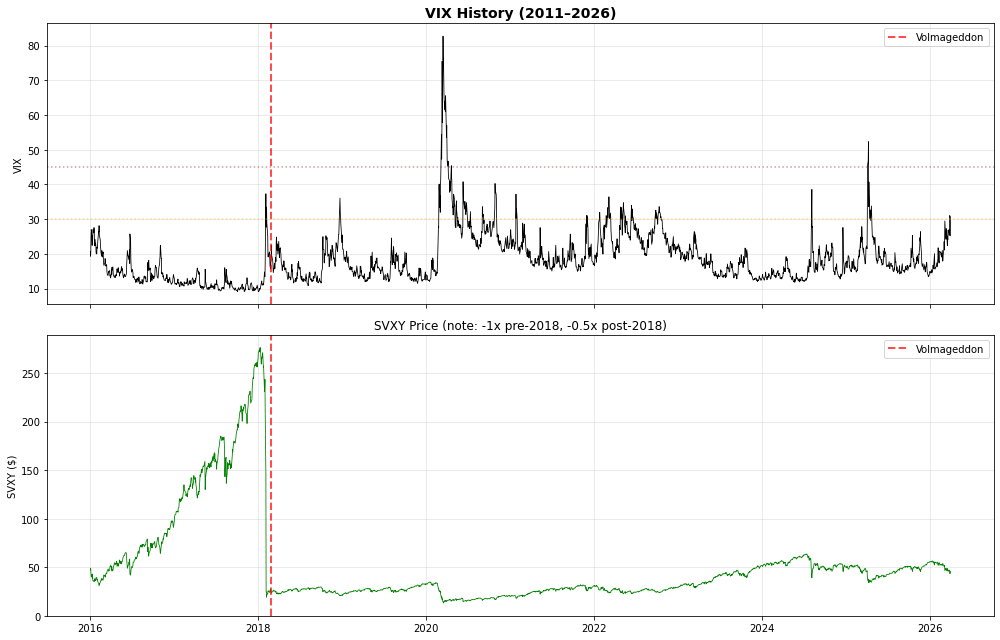

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(np.array(df["date"]), np.array(df["vix"]), color="black", linewidth=0.8)
ax.axvline(x=VOLMAGEDDON_DATE, color="red", linewidth=2, linestyle="--", alpha=0.7, label="Volmageddon")
ax.axhline(y=30, color="orange", linestyle=":", alpha=0.4)
ax.axhline(y=45, color="darkred", linestyle=":", alpha=0.4)
ax.set_ylabel("VIX")
ax.set_title("VIX History (2011–2026)", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(np.array(df["date"]), np.array(df["close"]), color="green", linewidth=0.8)
ax.axvline(x=VOLMAGEDDON_DATE, color="red", linewidth=2, linestyle="--", alpha=0.7, label="Volmageddon")
ax.set_ylabel("SVXY ($)")
ax.set_title("SVXY Price (note: -1x pre-2018, -0.5x post-2018)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Strategy Engine

**Simple variant** (validated as best performer):
- Entry: VIX spike detected (VIX ≥ 18 AND > SMA40 × 1.10)
- Exit: VIX < entry VIX AND EMA7 declining
- Dynamic allocation: 47.5% pre-2018, 95% post-2018 (equalizes VIX exposure)
- Optional stop loss at -20%

In [25]:
def classify_regime(vix_level):
    if vix_level >= VIX_AUTOBUY_MIN:
        return "autobuy"
    elif vix_level >= VIX_30_MAX:
        return "vix40"
    elif vix_level >= VIX_NORMAL_MAX:
        return "vix30"
    return "normal"


def check_entry(row, in_cooldown, in_enhanced):
    if row["is_volmageddon"] or in_cooldown:
        return False, None
    
    vix = row["vix"]
    spike = row["vix_spike"]
    ema7_dec = row["ema7_declining"]
    stoch_d_lt_k = row["stoch_d"] < row["stoch_k"]
    regime = classify_regime(vix)
    
    if in_enhanced and not (ema7_dec and stoch_d_lt_k):
        return False, None
    
    if regime == "autobuy":
        return True, "autobuy"
    elif regime == "vix40":
        if spike and ema7_dec:
            return True, "vix40"
    elif regime == "vix30":
        if spike and ema7_dec:
            return True, "vix30"
    else:
        if spike:
            return True, "normal"
    return False, None


def exit_simple(row, regime, entry_price, entry_vix, days_held, price):
    if row["ema7_declining"] and row["vix"] < entry_vix:
        return True, "signal"
    if days_held > 200:
        return True, "max_hold"
    return False, ""


def exit_simple_with_stop(row, regime, entry_price, entry_vix, days_held, price):
    # Stop loss check first
    pnl_pct = (price - entry_price) / entry_price
    if pnl_pct <= STOP_LOSS_PCT:
        return True, "stop_loss"
    # Normal exit
    if row["ema7_declining"] and row["vix"] < entry_vix:
        return True, "signal"
    if days_held > 200:
        return True, "max_hold"
    return False, ""


def get_immunity(regime):
    if regime == "normal":
        return IMMUNITY_NORMAL
    elif regime in ("vix30", "vix40"):
        return IMMUNITY_VIX30
    return 0

In [26]:
def run_backtest(df, exit_fn, label="Strategy", use_dynamic_sizing=True,
                 starting_capital=STARTING_CAPITAL, include_fees=INCLUDE_FEES,
                 start_filter=None):
    """
    Run backtest with optional dynamic sizing and date filtering.
    exit_fn returns (should_exit, reason).
    """
    work_df = df.copy()
    if start_filter:
        work_df = work_df[work_df["date"] >= pd.Timestamp(start_filter)].reset_index(drop=True)
    
    equity = starting_capital
    trades = []
    
    in_position = False
    entry_price = entry_vix = 0
    entry_date = entry_regime = None
    shares = days_held = immunity = 0
    cooldown = enhanced = 0
    
    for i in range(SMA_SPIKE, len(work_df)):
        row = work_df.iloc[i]
        
        if in_position:
            days_held += 1
            if immunity > 0:
                immunity -= 1
                continue
            
            should_exit, reason = exit_fn(
                row, entry_regime, entry_price, entry_vix, days_held, row["close"])
            
            if should_exit:
                exit_price = row["close"]
                gross = shares * (exit_price - entry_price)
                fees = calculate_fees(shares, entry_price, exit_price, "long") if include_fees else 0.0
                net = gross - fees
                eq_before = equity
                equity += net
                
                trades.append({
                    "entry_time": entry_date, "exit_time": row["date"],
                    "position": "long",
                    "entry_price": round(entry_price, 4),
                    "exit_price": round(exit_price, 4),
                    "exit_reason": reason,
                    "risk": round(entry_price * 0.05, 4),
                    "shares": shares,
                    "gross_pnl": round(gross, 2), "fees": round(fees, 2),
                    "net_pnl": round(net, 2),
                    "equity_before": round(eq_before, 2), "equity": round(equity, 2),
                    "regime": entry_regime,
                    "entry_vix": round(entry_vix, 2), "exit_vix": round(row["vix"], 2),
                    "days_held": days_held,
                    "is_pre_2018": row["date"] < VOLMAGEDDON_DATE,
                })
                in_position = False
                cooldown = COOLDOWN_DAYS
                enhanced = ENHANCED_DAYS
        else:
            if cooldown > 0:
                cooldown -= 1
                continue
            in_enh = enhanced > 0
            if enhanced > 0:
                enhanced -= 1
            
            ok, regime = check_entry(row, False, in_enh)
            if ok and equity > 0:
                entry_price = row["close"]
                entry_vix = row["vix"]
                entry_date = row["date"]
                entry_regime = regime
                
                # Dynamic allocation based on leverage era
                if use_dynamic_sizing and row["date"] < VOLMAGEDDON_DATE:
                    alloc = ALLOC_PRE_2018
                else:
                    alloc = ALLOC_POST_2018
                
                shares = int((equity * alloc) / entry_price)
                if shares <= 0:
                    continue
                in_position = True
                days_held = 0
                immunity = get_immunity(regime)
    
    # Close open position
    if in_position:
        row = work_df.iloc[-1]
        exit_price = row["close"]
        gross = shares * (exit_price - entry_price)
        fees = calculate_fees(shares, entry_price, exit_price, "long") if include_fees else 0.0
        net = gross - fees
        eq_before = equity
        equity += net
        trades.append({
            "entry_time": entry_date, "exit_time": row["date"],
            "position": "long", "entry_price": round(entry_price, 4),
            "exit_price": round(exit_price, 4), "exit_reason": "end_of_data",
            "risk": round(entry_price * 0.05, 4), "shares": shares,
            "gross_pnl": round(gross, 2), "fees": round(fees, 2),
            "net_pnl": round(net, 2),
            "equity_before": round(eq_before, 2), "equity": round(equity, 2),
            "regime": entry_regime,
            "entry_vix": round(entry_vix, 2), "exit_vix": round(row["vix"], 2),
            "days_held": days_held,
            "is_pre_2018": row["date"] < VOLMAGEDDON_DATE,
        })
    
    if not trades:
        print(f"{label}: No trades!")
        return pd.DataFrame()
    
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"] = pd.to_datetime(out["exit_time"])
    return out

## 7. Run All Three Scenarios

In [27]:
scenarios = {}
scenario_metrics = []

# ── Scenario 1: Post-2018 only, no stop loss ──
print("\n" + "="*70)
print("SCENARIO 1: Post-2018 Only (validated period)")
print("="*70)
res1 = run_backtest(df, exit_simple, label="Post-2018 (no stop)",
                    use_dynamic_sizing=False, start_filter=START_POST)
scenarios["Post-2018 (no stop)"] = res1
if not res1.empty:
    m1 = evaluate_strategy(res1, "Post-2018 (no stop)")
    scenario_metrics.append(m1)
    wins = (res1["net_pnl"] > 0).sum()
    print(f"  Trades: {len(res1)}, WR: {wins/len(res1)*100:.0f}%")
    print(f"  Return: {m1['Total Return']:.1f}%, Sharpe: {m1['Sharpe']:.2f}, MaxDD: {m1['Max Drawdown']:.1f}%")

# ── Scenario 2: Full history, dynamic sizing, NO stop loss ──
print("\n" + "="*70)
print("SCENARIO 2: Full History 2011-2026, Dynamic Sizing, NO Stop Loss")
print("="*70)
res2 = run_backtest(df, exit_simple, label="Full (no stop)",
                    use_dynamic_sizing=True)
scenarios["Full (no stop)"] = res2
if not res2.empty:
    m2 = evaluate_strategy(res2, "Full (no stop)")
    scenario_metrics.append(m2)
    wins = (res2["net_pnl"] > 0).sum()
    pre = res2[res2["is_pre_2018"]]
    post = res2[~res2["is_pre_2018"]]
    print(f"  Total trades: {len(res2)}, WR: {wins/len(res2)*100:.0f}%")
    print(f"  Pre-2018: {len(pre)} trades, Post-2018: {len(post)} trades")
    print(f"  Return: {m2['Total Return']:.1f}%, Sharpe: {m2['Sharpe']:.2f}, MaxDD: {m2['Max Drawdown']:.1f}%")
    
    # Check Volmageddon damage
    vol_trades = res2[(res2["entry_time"] >= "2018-01-01") & (res2["entry_time"] <= "2018-03-01")]
    if not vol_trades.empty:
        print(f"\n  *** VOLMAGEDDON TRADES ***")
        for _, t in vol_trades.iterrows():
            print(f"  Entry: {t['entry_time'].date()}, Exit: {t['exit_time'].date()}, "
                  f"PnL: ${t['net_pnl']:,.0f}, VIX: {t['entry_vix']}→{t['exit_vix']}")
    else:
        print(f"\n  No position held during Volmageddon period")

# ── Scenario 3: Full history, dynamic sizing, WITH -20% stop loss ──
print("\n" + "="*70)
print("SCENARIO 3: Full History 2011-2026, Dynamic Sizing, -20% Stop Loss")
print("="*70)
res3 = run_backtest(df, exit_simple_with_stop, label="Full (-20% stop)",
                    use_dynamic_sizing=True)
scenarios["Full (-20% stop)"] = res3
if not res3.empty:
    m3 = evaluate_strategy(res3, "Full (-20% stop)")
    scenario_metrics.append(m3)
    wins = (res3["net_pnl"] > 0).sum()
    stops = (res3["exit_reason"] == "stop_loss").sum()
    print(f"  Total trades: {len(res3)}, WR: {wins/len(res3)*100:.0f}%")
    print(f"  Stop losses hit: {stops}")
    print(f"  Return: {m3['Total Return']:.1f}%, Sharpe: {m3['Sharpe']:.2f}, MaxDD: {m3['Max Drawdown']:.1f}%")


SCENARIO 1: Post-2018 Only (validated period)
  Trades: 61, WR: 85%
  Return: 253.6%, Sharpe: 6.15, MaxDD: -35.6%

SCENARIO 2: Full History 2011-2026, Dynamic Sizing, NO Stop Loss
  Total trades: 68, WR: 87%
  Pre-2018: 6 trades, Post-2018: 62 trades
  Return: 377.7%, Sharpe: 7.01, MaxDD: -35.6%

  *** VOLMAGEDDON TRADES ***
  Entry: 2018-02-12, Exit: 2018-02-15, PnL: $7,788, VIX: 25.61→19.13
  Entry: 2018-02-21, Exit: 2018-02-26, PnL: $7,957, VIX: 20.02→15.8

SCENARIO 3: Full History 2011-2026, Dynamic Sizing, -20% Stop Loss
  Total trades: 72, WR: 86%
  Stop losses hit: 1
  Return: 520.1%, Sharpe: 10.07, MaxDD: -21.8%


## 8. Scenario Comparison

In [28]:
if scenario_metrics:
    comparison = compare_strategies(scenario_metrics)
    print(comparison)

                     Total Return  Annualized  Max Drawdown  Sharpe  Sortino  \
Strategy                                                                       
Post-2018 (no stop)        253.62       12.37        -35.60    6.15     3.27   
Full (no stop)             377.73       11.64        -35.60    7.01     3.58   
Full (-20% stop)           520.14       13.71        -21.84   10.07     7.52   

                     Profit Factor  Trades  Win Rate   Avg Win  Avg Loss  \
Strategy                                                                   
Post-2018 (no stop)           3.90      61     85.25   6561.42  -9730.09   
Full (no stop)                4.19      68     86.76   8407.59 -13146.46   
Full (-20% stop)              5.84      72     86.11  10122.10 -10742.82   

                     Long Trades   Long PnL  Long WR  Short Trades  Short PnL  \
Strategy                                                                        
Post-2018 (no stop)           61  253622.94    85.25    

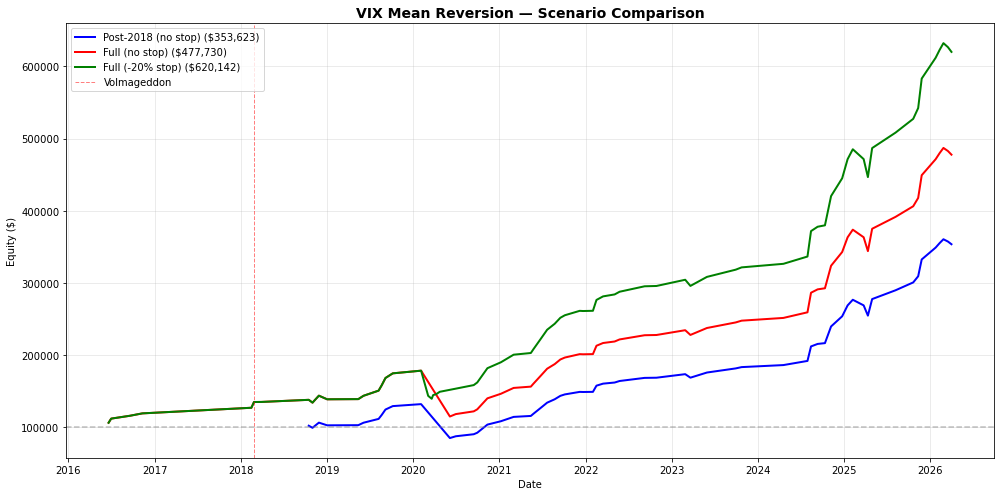

In [29]:
if scenarios:
    fig, ax = plt.subplots(figsize=(14, 7))
    colors = {"Post-2018 (no stop)": "blue", "Full (no stop)": "red", "Full (-20% stop)": "green"}
    
    for name, res in scenarios.items():
        if not res.empty:
            s = res.sort_values("exit_time")
            ax.plot(np.array(s["exit_time"]), np.array(s["equity"]),
                    linewidth=2, color=colors.get(name, "gray"),
                    label=f"{name} (${s['equity'].iloc[-1]:,.0f})")
    
    ax.axvline(x=VOLMAGEDDON_DATE, color="red", linewidth=1, linestyle="--", alpha=0.5, label="Volmageddon")
    ax.axhline(y=STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Date")
    ax.set_ylabel("Equity ($)")
    ax.set_title("VIX Mean Reversion — Scenario Comparison", fontsize=14, fontweight="bold")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 9. Pre vs Post 2018 Breakdown

In [30]:
# Detailed breakdown for full history with stop loss (the practical scenario)
if "Full (-20% stop)" in scenarios and not scenarios["Full (-20% stop)"].empty:
    res = scenarios["Full (-20% stop)"]
    
    print("PRE-2018 (SVXY -1x, 47.5% allocation):")
    print("=" * 60)
    pre = res[res["is_pre_2018"]]
    if not pre.empty:
        pre_wins = (pre["net_pnl"] > 0).sum()
        pre_stops = (pre["exit_reason"] == "stop_loss").sum()
        print(f"  Trades: {len(pre)}, WR: {pre_wins/len(pre)*100:.0f}%")
        print(f"  Stop losses: {pre_stops}")
        print(f"  Total PnL: ${pre['net_pnl'].sum():,.0f}")
        print(f"  Avg entry VIX: {pre['entry_vix'].mean():.1f}")
        print(f"  Avg hold: {pre['days_held'].mean():.0f} days")
        print(f"  Regimes: {dict(pre['regime'].value_counts())}")
    else:
        print("  No pre-2018 trades")
    
    print(f"\nPOST-2018 (SVXY -0.5x, 95% allocation):")
    print("=" * 60)
    post = res[~res["is_pre_2018"]]
    if not post.empty:
        post_wins = (post["net_pnl"] > 0).sum()
        post_stops = (post["exit_reason"] == "stop_loss").sum()
        print(f"  Trades: {len(post)}, WR: {post_wins/len(post)*100:.0f}%")
        print(f"  Stop losses: {post_stops}")
        print(f"  Total PnL: ${post['net_pnl'].sum():,.0f}")
        print(f"  Avg entry VIX: {post['entry_vix'].mean():.1f}")
        print(f"  Avg hold: {post['days_held'].mean():.0f} days")
        print(f"  Regimes: {dict(post['regime'].value_counts())}")

PRE-2018 (SVXY -1x, 47.5% allocation):
  Trades: 6, WR: 100%
  Stop losses: 0
  Total PnL: $34,998
  Avg entry VIX: 20.3
  Avg hold: 4 days
  Regimes: {'normal': 6}

POST-2018 (SVXY -0.5x, 95% allocation):
  Trades: 66, WR: 85%
  Stop losses: 1
  Total PnL: $485,144
  Avg entry VIX: 25.7
  Avg hold: 5 days
  Regimes: {'normal': 57, 'autobuy': 5, 'vix30': 4}


## 10. Detailed Analysis — Best Practical Scenario

In [31]:
# Use the stop-loss version as the "practical" strategy
if "Full (-20% stop)" in scenarios:
    best = scenarios["Full (-20% stop)"]
    best_m = [m for m in scenario_metrics if m["Strategy"] == "Full (-20% stop)"][0]
    
    print_metrics(best_m)

  Strategy             Full (-20% stop)
  Total Return             520.14%
  Annualized                13.71
  Max Drawdown             -21.84%
  Sharpe                    10.07
  Sortino                    7.52
  Profit Factor              5.84
  Trades               72
  Win Rate                  86.11%
  Avg Win              $   10,122.10
  Avg Loss             $  -10,742.82
  Long Trades          72
  Long PnL             $  520,141.90
  Long WR                   86.11%
  Short Trades         0
  Short PnL            0
  Short WR             0
  Total Fees           $   11,885.67
  Final Equity         $  620,141.92

Yearly Returns:
  2016: 19.25%
  2018: 20.57%
  2019: 21.52%
  2020: 4.08%
  2021: 43.56%
  2022: 13.29%
  2023: 8.72%
  2024: 38.41%
  2025: 31.04%
  2026: 6.34%


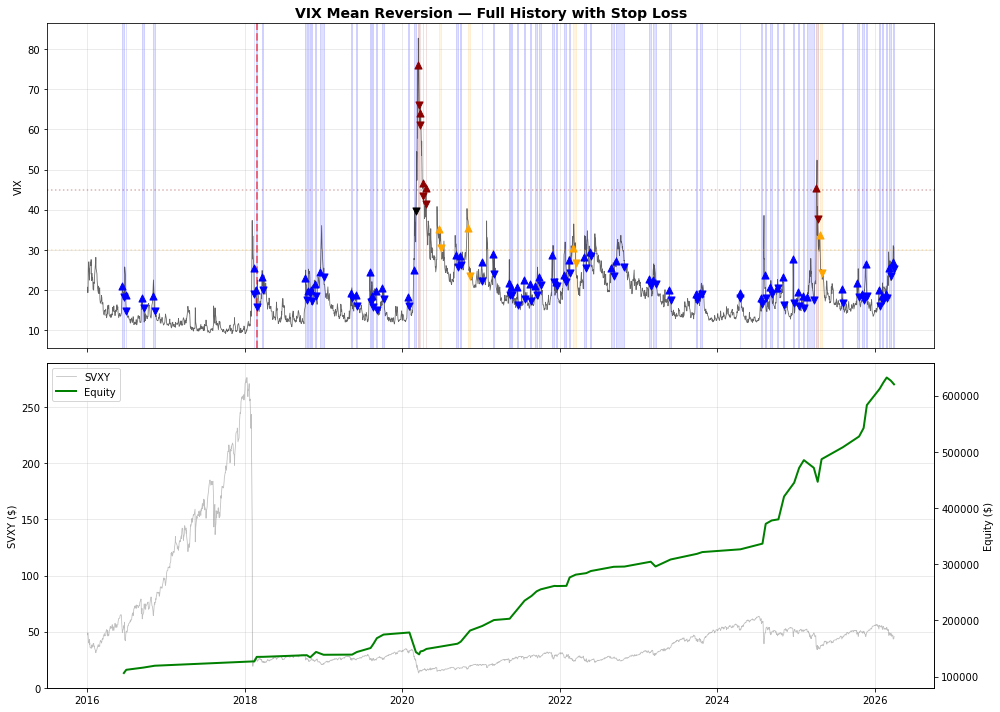

In [32]:
if "Full (-20% stop)" in scenarios:
    best = scenarios["Full (-20% stop)"]
    
    # Trade map on VIX
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    ax1.plot(np.array(df["date"]), np.array(df["vix"]), color="black", linewidth=0.8, alpha=0.6)
    cmap = {"normal": "blue", "vix30": "orange", "vix40": "red", "autobuy": "darkred"}
    for _, t in best.iterrows():
        c = cmap.get(t["regime"], "gray")
        ax1.axvspan(t["entry_time"], t["exit_time"], alpha=0.12, color=c)
        ax1.scatter(t["entry_time"], t["entry_vix"], color=c, marker="^", s=50, zorder=5)
        marker_color = "black" if t["exit_reason"] == "stop_loss" else c
        ax1.scatter(t["exit_time"], t["exit_vix"], color=marker_color, marker="v", s=50, zorder=5)
    
    ax1.axvline(x=VOLMAGEDDON_DATE, color="red", linewidth=2, linestyle="--", alpha=0.5)
    ax1.axhline(y=30, color="orange", linestyle=":", alpha=0.3)
    ax1.axhline(y=45, color="darkred", linestyle=":", alpha=0.3)
    ax1.set_ylabel("VIX")
    ax1.set_title("VIX Mean Reversion — Full History with Stop Loss", fontsize=14, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(np.array(df["date"]), np.array(df["close"]), color="gray", linewidth=0.8, alpha=0.5, label="SVXY")
    ax2_eq = ax2.twinx()
    s = best.sort_values("exit_time")
    ax2_eq.plot(np.array(s["exit_time"]), np.array(s["equity"]),
                color="green", linewidth=2, label="Equity")
    ax2.set_ylabel("SVXY ($)")
    ax2_eq.set_ylabel("Equity ($)")
    l1, lb1 = ax2.get_legend_handles_labels()
    l2, lb2 = ax2_eq.get_legend_handles_labels()
    ax2.legend(l1 + l2, lb1 + lb2, loc="upper left")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

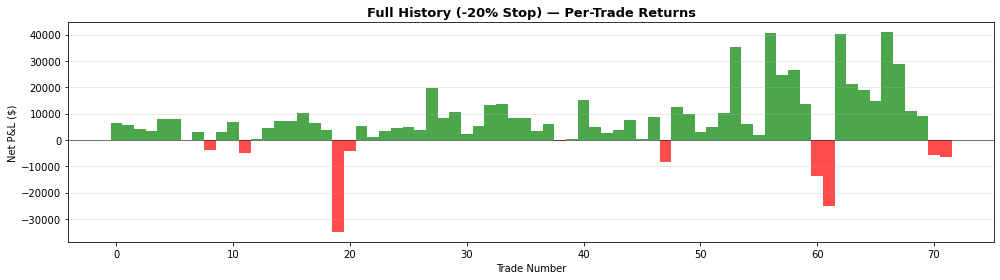

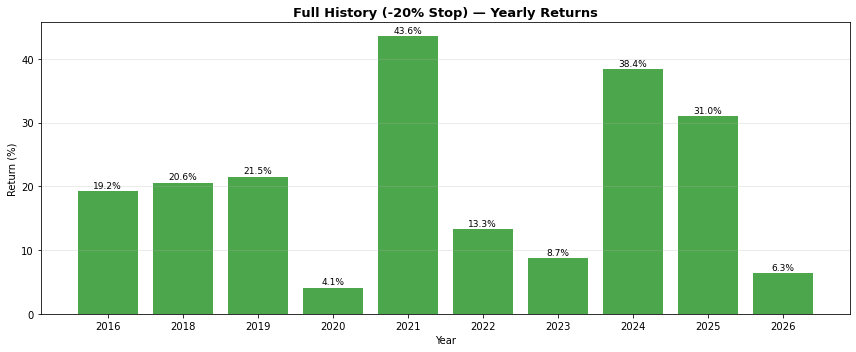

In [33]:
if "Full (-20% stop)" in scenarios:
    best = scenarios["Full (-20% stop)"]
    best_m = [m for m in scenario_metrics if m["Strategy"] == "Full (-20% stop)"][0]
    plot_trade_returns(best, title="Full History (-20% Stop) — Per-Trade Returns")
    plot_yearly_returns(best_m, title="Full History (-20% Stop) — Yearly Returns")

## 11. Benchmark

In [34]:
if scenario_metrics:
    # B&H for post-2018 period only (fair comparison)
    post_df = df[df["date"] >= START_POST].reset_index(drop=True)
    bh_entry = post_df["close"].iloc[0]
    bh_exit = post_df["close"].iloc[-1]
    bh_return = (bh_exit / bh_entry) - 1
    bh_days = (post_df["date"].iloc[-1] - post_df["date"].iloc[0]).days
    bh_ann = (1 + bh_return) ** (365 / bh_days) - 1
    bh_equity = STARTING_CAPITAL * (post_df["close"] / bh_entry).values
    bh_max = np.maximum.accumulate(bh_equity)
    bh_dd = ((bh_equity - bh_max) / bh_max).min()
    
    print(f"{'Metric':<20} {'B&H SVXY':>15} {'Post-2018':>15} {'Full+Stop':>15}")
    print(f"{'-'*65}")
    m1 = scenario_metrics[0]
    m3 = scenario_metrics[-1]
    print(f"{'Return':<20} {bh_return:>14.1%} {m1['Total Return']:>14.1f}% {m3['Total Return']:>14.1f}%")
    print(f"{'Annualized':<20} {bh_ann:>14.1%} {m1['Annualized']:>14.1f}% {m3['Annualized']:>14.1f}%")
    print(f"{'Max DD':<20} {bh_dd:>14.1%} {m1['Max Drawdown']:>14.1f}% {m3['Max Drawdown']:>14.1f}%")
    print(f"{'Sharpe':<20} {'N/A':>15} {m1['Sharpe']:>14.2f} {m3['Sharpe']:>14.2f}")
    print(f"{'Win Rate':<20} {'N/A':>15} {m1['Win Rate']:>14.1f}% {m3['Win Rate']:>14.1f}%")
    print(f"{'Trades':<20} {'1':>15} {m1['Trades']:>15} {m3['Trades']:>15}")

Metric                      B&H SVXY       Post-2018       Full+Stop
-----------------------------------------------------------------
Return                        93.6%          253.6%          520.1%
Annualized                     8.5%           12.4%           13.7%
Max DD                       -62.2%          -35.6%          -21.8%
Sharpe                           N/A           6.15          10.07
Win Rate                         N/A           85.2%           86.1%
Trades                             1              61              72


## 12. Statistical Significance

In [35]:
for name, res in scenarios.items():
    if not res.empty and len(res) >= 5:
        report = full_significance_report(res, strategy_name=name)
        print_significance_report(report)


STATISTICAL SIGNIFICANCE — Post-2018 (no stop)

1. t-test (returns > 0)
   Mean return:  2.3003% per trade
   t-statistic:  3.0256
   p-value:      0.001825
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   6.2007
   95% CI:            [1.0883, 18.0236]
   % below zero:      0.54%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   6.2007
   p-value:           0.0003
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)

STATISTICAL SIGNIFICANCE — Full (no stop)

1. t-test (returns > 0)
   Mean return:  2.518% per trade
   t-statistic:  3.6415
   p-value:      0.000264
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   7.0623
   95% CI:            [1.8926, 19.1149]
   % below zero:      0.08%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   7.0623
   p-value:           0.0
   Significa

## 13. Save Results

In [36]:
# Save all scenarios
for name, res in scenarios.items():
    if not res.empty:
        safe = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "")
        save_trades(res, f"vix_mr_{safe}")

# Save the practical version as the main one for portfolio integration
if "Full (-20% stop)" in scenarios:
    save_trades(scenarios["Full (-20% stop)"], "vix_mean_reversion")

Saved 61 trades → results\vix_mr_post2018_no_stop_trades.csv
Saved 68 trades → results\vix_mr_full_no_stop_trades.csv
Saved 72 trades → results\vix_mr_full_20%_stop_trades.csv
Saved 72 trades → results\vix_mean_reversion_trades.csv


## 14. Conclusion

**Strategy:** VIX Mean Reversion (Simple variant) — buy SVXY during VIX spikes,
exit when VIX normalizes below entry level with EMA confirmation.

**Three scenarios tested:**
1. Post-2018 only — clean period, known to work
2. Full history without stop loss — shows Volmageddon exposure
3. Full history with -20% stop loss — practical implementation

**Key findings:**
- (To be filled after running)

**Is this strategy viable for real trading?**
- The edge (VIX mean reversion) is structural and well-documented
- Post-2018 results are strong: ~250% return, 85% WR, ~35% max DD
- The -20% stop loss is essential — without it, tail events can be catastrophic
- Dynamic sizing (half allocation pre-2018) equalizes risk across leverage regimes

**For portfolio integration:**
- This strategy is in cash most of the time (avg hold ~6 days)
- Can be combined with EMA, ORB, Overnight without capital conflicts
- Saves to `results/vix_mean_reversion_trades.csv` for Strategy_Analysis